[SUMMARY] Frames in file: 2
  - Frame 000: name='1', cells=10
  - Frame 001: name='5', cells=18


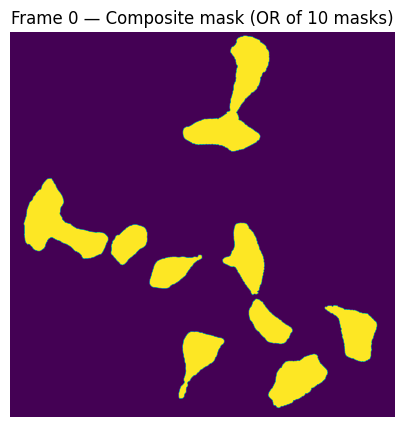

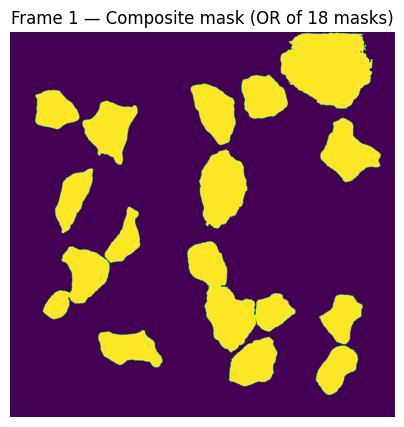

In [2]:
# Jupyter helper: Inspect & visualize masks from your exported .mat file

import numpy as np
import scipy.io
import pathlib
import matplotlib.pyplot as plt

# ---------- Configure this ----------
# 1) Put the absolute path to your exported MAT file here:
MAT_PATH = pathlib.Path(r"C:\Users\tkpp2\Documents\FISH-ML\FISH-ML\assets\kayleigh\testingkayleighmat.mat")   # <-- EDIT ME
# ------------------------------------


def _load_tracked(mat_path: pathlib.Path):
    """
    Load the 'Tracked' variable written by your exporter.
    This uses scipy.io.loadmat and returns the raw numpy structure.
    """
    if not mat_path.exists():
        raise FileNotFoundError(f"MAT file not found: {mat_path}")
    mat = scipy.io.loadmat(mat_path, struct_as_record=False, squeeze_me=False)
    if "Tracked" not in mat:
        raise KeyError("No 'Tracked' variable found in MAT file.")
    return mat["Tracked"]


def _frame_struct(tracked, i: int):
    """
    Your file stores a 1xN object array, where each element is a (1,1) structured array.
    This helper unwraps that to the single struct object for frame i.
    """
    return tracked[0, i][0, 0]


def get_num_frames(tracked) -> int:
    return tracked.shape[1]


def get_frame_name(tracked, i: int) -> str:
    s = _frame_struct(tracked, i)
    # filename stored as a nested object array [[name]]
    return str(s.filename[0, 0][0])


def get_num_cells(tracked, i: int) -> int:
    s = _frame_struct(tracked, i)
    return s.cells.shape[1] if s.cells.size else 0


def get_cell_struct(tracked, i: int, j: int):
    """
    Inside s.cells is a 1 x cellCount object array; each is itself a (1,1) struct.
    """
    s = _frame_struct(tracked, i)
    return s.cells[0, j][0, 0]


def get_cell_mask(tracked, i: int, j: int) -> np.ndarray:
    """
    Returns the mask as a 2D numpy array. Export stored it as double; we binarize to bool.
    """
    cs = get_cell_struct(tracked, i, j)
    # Expect a 2D array (H, W) of floats; turn into boolean mask
    m = np.array(cs.mask, dtype=float)
    if m.ndim != 2:
        # If mask somehow has shape (1,1) or weird dims, try to squeeze
        m = np.squeeze(m)
    return (m > 0.5).astype(np.uint8)


def get_cell_pos_xy(tracked, i: int, j: int):
    """
    Returns the 'pos' array saved for that cell (transposed to [2, K] by the exporter).
    We convert back to a list of (x, y) tuples for convenience.
    """
    cs = get_cell_struct(tracked, i, j)
    pos = np.array(cs.pos)
    pos = np.squeeze(pos)  # expected shape (2, K)
    if pos.ndim == 2 and pos.shape[0] == 2:
        xs, ys = pos[0], pos[1]
        return list(zip(xs.tolist(), ys.tolist()))
    return []


def summarize_mat(mat_path: pathlib.Path):
    tracked = _load_tracked(mat_path)
    n_frames = get_num_frames(tracked)
    print(f"[SUMMARY] Frames in file: {n_frames}")
    for i in range(n_frames):
        name = get_frame_name(tracked, i)
        n_cells = get_num_cells(tracked, i)
        print(f"  - Frame {i:03d}: name={name!r}, cells={n_cells}")
    return tracked


def show_frame_masks(tracked, i: int, max_cells: int = 9):
    """
    Visualize up to `max_cells` masks for frame i as a grid.
    """
    n_cells = get_num_cells(tracked, i)
    n_show = min(n_cells, max_cells)
    if n_show == 0:
        print(f"[INFO] Frame {i} has no cells/masks.")
        return

    # grid size
    cols = int(np.ceil(np.sqrt(n_show)))
    rows = int(np.ceil(n_show / cols))

    fig = plt.figure(figsize=(cols * 3, rows * 3))
    fig.suptitle(f"Frame {i} — showing {n_show}/{n_cells} masks", y=0.98)

    for k in range(n_show):
        ax = fig.add_subplot(rows, cols, k + 1)
        m = get_cell_mask(tracked, i, k)
        ax.imshow(m)
        ax.set_title(f"Cell {k}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def show_composite_mask(tracked, i: int):
    """
    Visualize a single composite mask for frame i (logical OR across all cells).
    """
    n_cells = get_num_cells(tracked, i)
    if n_cells == 0:
        print(f"[INFO] Frame {i} has no cells/masks.")
        return

    comp = None
    for j in range(n_cells):
        m = get_cell_mask(tracked, i, j).astype(bool)
        comp = m if comp is None else (comp | m)

    comp = comp.astype(np.uint8)

    plt.figure(figsize=(5, 5))
    plt.title(f"Frame {i} — Composite mask (OR of {n_cells} masks)")
    plt.imshow(comp)
    plt.axis("off")
    plt.show()


# ---- Run a quick summary and show composite masks for all frames ----
try:
    tracked = summarize_mat(MAT_PATH)
    n_frames = get_num_frames(tracked)
    for i in range(n_frames):
        show_composite_mask(tracked, i)
except Exception as e:
    print("ERROR:", e)